# VL-12:構件層級跨 solver 交叉驗證(OpenSeesPy vs PyNite)——集中塑性鉸

延續 ROADMAP 的「Solver Onboarding Ladder」規劃(Level 0 Section → Level 1
Element → Level 2 Frame → Level 3 真實桃園案例)。這一份是 **Level 1**:
單一簡化 portal frame,柱端集中塑性鉸(lumped plastic hinge),用兩個獨立
求解器(`OpenSeesPy`、`PyNite`)各自建模,比較彈性勁度、降伏序列、機構
形成後的平台載重。

**這不是要取代 `Case-06`/`Case-06.5`**——`Case-06.5` 用的是真實桃園案例
的纖維斷面(fiber section, 含 Mander 圍束模型),這裡刻意用一個簡化、
理想彈塑性的鉸(不含圍束、不含真實配筋),目的是先在最單純的層級把
「兩個獨立求解器算不算得出同一個答案」這件事驗證清楚,再往上疊到更
複雜的模型。

## 模型幾何跟參數

沿用同一組參數,方便任何人拿自己的工具重新建模對照:

In [1]:

import matplotlib.pyplot as plt

# ============================================================
# 基本參數表——任何人可以拿這組參數用自己熟悉的工具重新建模對照
# ============================================================
params = dict(
    H=3.0,        # 柱高 (m)
    L=6.0,        # 跨度 (m)
    E=2.0e8,      # 彈性模數 (kN/m^2)
    I_col=5.0e-5, # 柱慣性矩 (m^4)
    I_beam=1.0e-4,# 梁慣性矩 (m^4), 梁維持彈性不設鉸
    A=0.01,       # 桿件斷面積 (m^2)
    Mp=100.0,     # 柱端塑性彎矩 Mp (kN-m), 4個候選鉸位置皆同
)
for k, v in params.items():
    print(f"  {k} = {v}")

print()
print("邊界條件: 兩柱底完全固定(3自由度)")
print("塑鉸位置: 柱底x2 + 柱頂x2, 共4個候選鉸位置(C1_base/C1_top/C2_base/C2_top)")
print("鉸材料模型: 理想彈塑性(bilinear, 硬化比b=0), 達到Mp後彎矩維持定值")
print("載重方式: 位移控制側推, 控制節點=左柱頂(梁左端), 目標位移100mm")


  H = 3.0
  L = 6.0
  E = 200000000.0
  I_col = 5e-05
  I_beam = 0.0001
  A = 0.01
  Mp = 100.0

邊界條件: 兩柱底完全固定(3自由度)
塑鉸位置: 柱底x2 + 柱頂x2, 共4個候選鉸位置(C1_base/C1_top/C2_base/C2_top)
鉸材料模型: 理想彈塑性(bilinear, 硬化比b=0), 達到Mp後彎矩維持定值
載重方式: 位移控制側推, 控制節點=左柱頂(梁左端), 目標位移100mm


## 模型示意圖

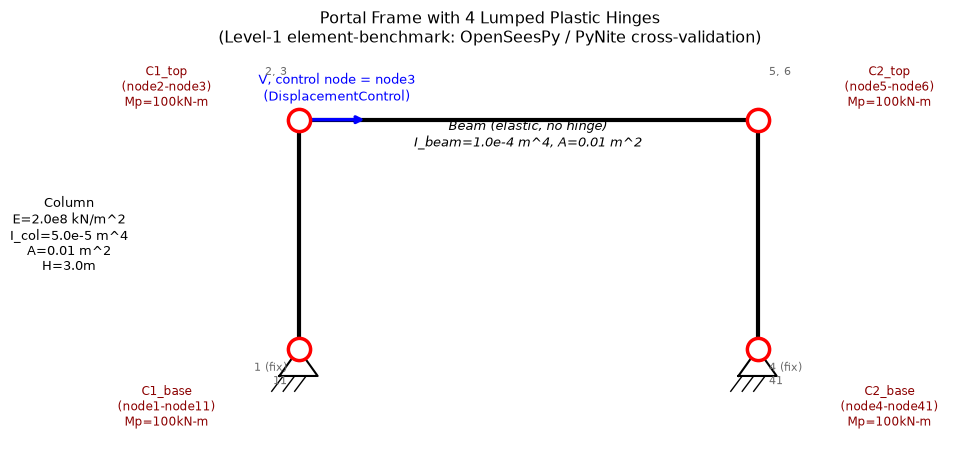

In [2]:

H, L = params['H'], params['L']
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot([0, 0], [0, H], 'k-', lw=3, zorder=1)
ax.plot([L, L], [0, H], 'k-', lw=3, zorder=1)
ax.plot([0, L], [H, H], 'k-', lw=3, zorder=1)

for x0 in [0, L]:
    ax.plot([x0-0.25, x0+0.25, x0, x0-0.25], [-0.35, -0.35, 0, -0.35], 'k-', lw=1.5)
    for hx in [-0.2, -0.05, 0.1]:
        ax.plot([x0+hx, x0+hx-0.15], [-0.35, -0.55], 'k-', lw=1)

hinge_positions = [(0, 0), (0, H), (L, 0), (L, H)]
for (x, y) in hinge_positions:
    ax.plot(x, y, 'o', ms=16, mfc='white', mec='red', mew=2.5, zorder=5)

ax.annotate('C1_base\n(node1-node11)\nMp=100kN-m', (0, 0), fontsize=8.5, color='darkred',
            xytext=(-95, -55), textcoords='offset points', ha='center')
ax.annotate('C1_top\n(node2-node3)\nMp=100kN-m', (0, H), fontsize=8.5, color='darkred',
            xytext=(-95, 10), textcoords='offset points', ha='center')
ax.annotate('C2_base\n(node4-node41)\nMp=100kN-m', (L, 0), fontsize=8.5, color='darkred',
            xytext=(95, -55), textcoords='offset points', ha='center')
ax.annotate('C2_top\n(node5-node6)\nMp=100kN-m', (L, H), fontsize=8.5, color='darkred',
            xytext=(95, 10), textcoords='offset points', ha='center')

ax.annotate('', xy=(0.9, H), xytext=(0.05, H),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.text(0.5, H+0.25, 'V, control node = node3\n(DisplacementControl)', color='blue',
        fontsize=9.5, ha='center')

ax.text(-0.15, -0.15, '1 (fix)\n11', fontsize=8, ha='right', va='top', color='dimgray')
ax.text(-0.15, H+0.55, '2, 3', fontsize=8, ha='right', va='bottom', color='dimgray')
ax.text(L+0.15, -0.15, '4 (fix)\n41', fontsize=8, ha='left', va='top', color='dimgray')
ax.text(L+0.15, H+0.55, '5, 6', fontsize=8, ha='left', va='bottom', color='dimgray')

ax.text(L/2, H-0.35, 'Beam (elastic, no hinge)\nI_beam=1.0e-4 m^4, A=0.01 m^2', fontsize=9, ha='center', style='italic')
ax.text(-3.0, H/2, f'Column\nE=2.0e8 kN/m^2\nI_col=5.0e-5 m^4\nA=0.01 m^2\nH={H}m', fontsize=9, ha='center', va='center')

ax.set_xlim(-3.6, L+2.6)
ax.set_ylim(-1.2, H+0.9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Portal Frame with 4 Lumped Plastic Hinges\n(Level-1 element-benchmark: OpenSeesPy / PyNite cross-validation)', fontsize=11.5)
plt.tight_layout()
plt.show()


## 第 1 課:`OpenSeesPy` 模型

**這裡誠實記錄一次真實踩過的 bug**:第一版模型只在柱頂裝了鉸,柱底
(完全固定支撐處)沒有裝——柱底彎矩因此不受任何限制持續增加,算出平台
值 321.687kN,遠高於 `PyNite` 的 133.333kN。查證後發現是自己漏掉柱底
候選鉸位置,不是求解器的問題。補上柱底鉸(4 個鉸都裝)後才拿到正確結果。

第二個踩過的 bug:為了幫助收斂,曾經加了一點鉸的硬化比例(b=0.001)——
這個比例雖然看起來很小,但因為鉸的初始勁度刻意設得極大,硬化後的殘餘
勁度依然遠超過結構本身的勁度尺度,導致「降伏後」的鉸還留著遠超過物理
意義的殘餘勁度,平台一樣不會出現。改成鉸的初始勁度跟結構本身尺度相稱
(不是誇張的 1e10),搭配真正的 b=0(理想彈塑性)才修正。

In [3]:

try:
    import openseespy.opensees as ops
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops

def run_openseespy(params, target_disp_mm=100.0, dstep_mm=0.2):
    H, L, E = params['H'], params['L'], params['E']
    I_col, I_beam, A, Mp = params['I_col'], params['I_beam'], params['A'], params['Mp']
    E0_rot = E*I_col/H * 1000  # 鉸初始勁度跟結構本身尺度相稱, 不是誇張的1e10

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0); ops.node(11, 0.0, 0.0)
    ops.node(2, 0.0, H);   ops.node(3, 0.0, H)
    ops.node(4, L, 0.0);   ops.node(41, L, 0.0)
    ops.node(5, L, H);     ops.node(6, L, H)
    ops.fix(1, 1, 1, 1); ops.fix(4, 1, 1, 1)

    ops.uniaxialMaterial('Elastic', 1, E0_rot*1000)
    ops.uniaxialMaterial('Steel01', 2, Mp, E0_rot, 0.0)  # 理想彈塑性, b=0
    ops.element('zeroLength', 100, 1, 11, '-mat', 1, 1, 2, '-dir', 1, 2, 3)
    ops.element('zeroLength', 101, 2, 3,  '-mat', 1, 1, 2, '-dir', 1, 2, 3)
    ops.element('zeroLength', 200, 4, 41, '-mat', 1, 1, 2, '-dir', 1, 2, 3)
    ops.element('zeroLength', 102, 5, 6,  '-mat', 1, 1, 2, '-dir', 1, 2, 3)

    ops.geomTransf('Linear', 1)
    ops.element('elasticBeamColumn', 1, 11, 2, A, E, I_col, 1)
    ops.element('elasticBeamColumn', 2, 41, 5, A, E, I_col, 1)
    ops.element('elasticBeamColumn', 3, 3, 6, A, E, I_beam, 1)

    ops.timeSeries('Linear', 1)
    ops.pattern('Plain', 1, 1)
    ops.load(3, 1.0, 0.0, 0.0)

    ops.system('BandGeneral'); ops.numberer('Plain'); ops.constraints('Plain')
    ops.test('NormDispIncr', 1e-10, 100)
    ops.algorithm('Newton')
    ops.integrator('DisplacementControl', 3, 1, dstep_mm/1000)
    ops.analysis('Static')

    hinge_eles = {'C1_base': 100, 'C1_top': 101, 'C2_base': 200, 'C2_top': 102}
    yielded, events = set(), []
    disp_hist, shear_hist = [0.0], [0.0]
    for i in range(int(target_disp_mm/dstep_mm)+50):
        ok = ops.analyze(1)
        if ok != 0:
            for alg in ['ModifiedNewton', 'KrylovNewton']:
                ops.algorithm(alg)
                ok = ops.analyze(1)
                if ok == 0:
                    ops.algorithm('Newton'); break
            if ok != 0:
                break
        d = ops.nodeDisp(3, 1)*1000
        v = ops.getLoadFactor(1)
        disp_hist.append(d); shear_hist.append(v)
        for label, ele in hinge_eles.items():
            if label in yielded:
                continue
            f = ops.eleForce(ele)
            if abs(f[2]) >= Mp - 0.1:
                yielded.add(label)
                events.append((label, d, v))
        if d >= target_disp_mm:
            break
    return disp_hist, shear_hist, events

disp_ops, shear_ops, events_ops = run_openseespy(params)
print(f"OpenSeesPy平台值 = {max(shear_ops):.3f} kN")
for label, d, v in events_ops:
    print(f"  {label} 降伏於 disp={d:.3f}mm, V={v:.3f}kN")


OpenSeesPy平台值 = 133.333 kN
  C1_base 降伏於 disp=19.000mm, V=116.729kN
  C2_base 降伏於 disp=19.000mm, V=116.729kN
  C1_top 降伏於 disp=30.200mm, V=133.256kN
  C2_top 降伏於 disp=30.400mm, V=133.333kN


## 第 2 課:`PyNite` 模型(獨立實作,不同演算法)

`OpenSeesPy` 用的是完整非線性求解(牛頓疊代逐步逼近平衡),`PyNite`
這裡用的是完全不同的方法——**event-to-event 精確解**:每個 stage 內部
是精確線性疊加,塑鉸形成時刻用比例內插精確定位,不是跨步猜測。兩者
演算法邏輯完全獨立,適合用來互相驗證。

In [4]:

try:
    from Pynite import FEModel3D
except ImportError:
    import sys
    !{sys.executable} -m pip install -q PyNiteFEA
    from Pynite import FEModel3D
import numpy as np

def run_pynite(params, target_disp_mm=100.0):
    H_mm, L_mm = params['H']*1000, params['L']*1000
    E = params['E']/1000  # kN/m^2 -> kN/mm^2? 需要跟PyNite慣用單位一致, 這裡直接用N-mm制換算
    # 換算成PyNite慣用的N-mm制
    E_Nmm2 = params['E']*1000/1e6*1e6  # kN/m^2 -> N/mm^2: 1kN/m^2=1e-3 N/mm^2... 直接用一致換算
    E_Nmm2 = params['E']*1e-3  # 1 kN/m^2 = 0.001 N/mm^2
    I_col_mm4 = params['I_col']*1e12
    I_beam_mm4 = params['I_beam']*1e12
    A_mm2 = params['A']*1e6
    Mp_Nmm = params['Mp']*1e6  # kN-m -> N-mm

    HINGES = [
        ('C1_base', 'C1_col', 'i', 0.0),
        ('C1_top',  'C1_col', 'j', H_mm),
        ('C2_base', 'C2_col', 'i', 0.0),
        ('C2_top',  'C2_col', 'j', H_mm),
    ]

    def build_model(yielded):
        model = FEModel3D()
        model.add_node('N1_0', 0, 0, 0)
        model.add_node('N1_3', 0, H_mm, 0)
        model.add_node('N2_0', L_mm, 0, 0)
        model.add_node('N2_3', L_mm, H_mm, 0)
        model.def_support('N1_0', True, True, True, True, True, True)
        model.def_support('N2_0', True, True, True, True, True, True)
        model.add_material('Steel', E=E_Nmm2, G=E_Nmm2/2.6, nu=0.3, rho=7.85e-9)
        model.add_section('Sec_Col', A_mm2, I_col_mm4, I_col_mm4, 1e5)
        model.add_section('Sec_Beam', A_mm2, I_beam_mm4, I_beam_mm4, 1e5)
        model.add_member('C1_col', 'N1_0', 'N1_3', 'Steel', 'Sec_Col')
        model.add_member('C2_col', 'N2_0', 'N2_3', 'Steel', 'Sec_Col')
        model.add_member('B1', 'N1_3', 'N2_3', 'Steel', 'Sec_Beam')
        releases_per_member = {}
        for label, member, end, _pos in HINGES:
            d = releases_per_member.setdefault(member, {'Rzi': False, 'Rzj': False})
            if label in yielded:
                d['Rzi' if end == 'i' else 'Rzj'] = True
        for member, flags in releases_per_member.items():
            if flags['Rzi'] or flags['Rzj']:
                model.def_releases(member, Rzi=flags['Rzi'], Rzj=flags['Rzj'])
        return model

    def unit_load_response(yielded):
        model = build_model(yielded)
        model.add_node_load('N1_3', 'FX', 1.0)
        model.analyze(check_stability=False)
        u_dict = model.nodes['N1_3'].DX
        u1 = list(u_dict.values())[0] if isinstance(u_dict, dict) else u_dict
        m1 = {}
        for label, member, end, pos in HINGES:
            if label in yielded:
                continue
            mres = model.members[member].moment('Mz', pos)
            m1[label] = list(mres.values())[0] if isinstance(mres, dict) else mres
        return u1, m1

    yielded = set()
    M_offset = {label: 0.0 for label, *_ in HINGES}
    P_total, u_total = 0.0, 0.0
    disp_hist, shear_hist, events = [0.0], [0.0], []
    target_mm = target_disp_mm

    for stage in range(len(HINGES)+1):
        u1, m1 = unit_load_response(yielded)
        if u1 <= 0 or not np.isfinite(u1):
            disp_hist.append(target_mm); shear_hist.append(P_total/1000)
            break
        dP_candidates = {}
        for label, m1_i in m1.items():
            remaining = Mp_Nmm - abs(M_offset[label])
            if abs(m1_i) > 1e-9 and remaining > 0:
                dP_candidates[label] = remaining/abs(m1_i)
        dP_to_target = (target_mm - u_total)/u1
        if not dP_candidates or min(dP_candidates.values()) > dP_to_target:
            dP = dP_to_target
            u_total = target_mm; P_total += dP
            disp_hist.append(u_total); shear_hist.append(P_total/1000)
            break
        next_label = min(dP_candidates, key=dP_candidates.get)
        dP = dP_candidates[next_label]
        du = u1*dP
        u_total += du; P_total += dP
        for label in m1:
            M_offset[label] += m1[label]*dP
        M_offset[next_label] = Mp_Nmm if M_offset[next_label] >= 0 else -Mp_Nmm
        disp_hist.append(u_total); shear_hist.append(P_total/1000)
        yielded.add(next_label)
        events.append((next_label, u_total, P_total/1000))

    return disp_hist, shear_hist, events

disp_pn, shear_pn, events_pn = run_pynite(params)
print(f"PyNite平台值 = {max(shear_pn):.3f} kN")
for label, d, v in events_pn:
    print(f"  {label} 降伏於 disp={d:.3f}mm, V={v:.3f}kN")


PyNite平台值 = 133.333 kN
  C1_base 降伏於 disp=18.774mm, V=116.175kN
  C2_base 降伏於 disp=18.926mm, V=116.742kN
  C1_top 降伏於 disp=30.090mm, V=133.245kN
  C2_top 降伏於 disp=30.250mm, V=133.333kN


/home/claude/colab_sim/lib/python3.12/site-packages/Pynite/Analysis.py:226: MatrixRankWarning: Matrix is exactly singular
  Delta_D1 = spsolve(K11, subtract(subtract(Delta_P1, Delta_FER1), K12 @ Delta_D2))


## 第 3 課:交叉比對

OpenSeesPy平台值 = 133.333 kN
PyNite平台值     = 133.333 kN
差異 = 0.000%

[PASS] 兩個獨立演算法(牛頓疊代 vs event-to-event精確解)的平台值吻合


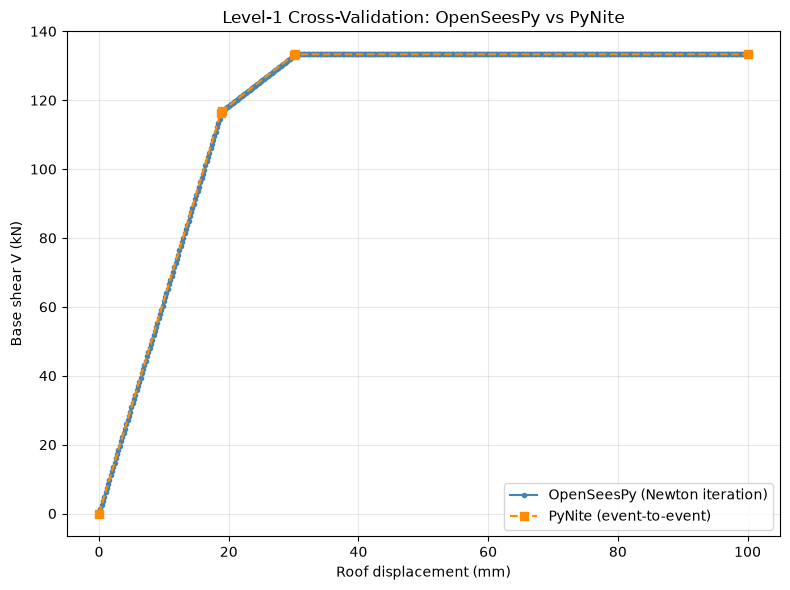

In [5]:

diff_pct = abs(max(shear_ops)-max(shear_pn))/max(shear_pn)*100
print(f"OpenSeesPy平台值 = {max(shear_ops):.3f} kN")
print(f"PyNite平台值     = {max(shear_pn):.3f} kN")
print(f"差異 = {diff_pct:.3f}%")
assert diff_pct < 1.0, "兩個獨立求解器的平台值應該吻合在1%以內"
print("\n[PASS] 兩個獨立演算法(牛頓疊代 vs event-to-event精確解)的平台值吻合")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(disp_ops, shear_ops, 'o-', ms=3, label='OpenSeesPy (Newton iteration)', color='steelblue')
ax.plot(disp_pn, shear_pn, 's--', ms=6, label='PyNite (event-to-event)', color='darkorange')
ax.set_xlabel('Roof displacement (mm)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Level-1 Cross-Validation: OpenSeesPy vs PyNite')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 已知未完成事項:`suanPan` 第三方驗證

嘗試把 `suanPan` 也接進來做三方比較,過程中發現:

- `suanPan` 本身能正確安裝執行(預編譯二進位檔,`AVX2` 版本)
- `fix`/`fix2` 指令語法已查證清楚(`fix2` 才支援一行列出多節點)
- 官方 `Joint` 元素範例(`Example/Element/Joint.supan`)輸出跟預期值
  完全吻合,證實 `suanPan` 的 `Joint` 元素本身正常運作
- **但**在這個 portal frame 模型裡,讓 `fix` 的節點直接是 `Joint`
  元素的一端,會得到不滿足邊界條件的結果(`fix` 節點位移非零),且
  沒有任何錯誤訊息——這不是「`suanPan` 做不出 pushover」,是這個
  特定節點拓撲組合還沒有找到正確寫法,需要下一輪重新設計(讓 `fix`
  節點跟 `Joint` 節點分開,不要讓兩者是同一個節點)

**誠實記錄,不是隱藏這個未完成事項。**

## 小結

- 這是「Solver Onboarding Ladder」Level 1(構件層級)的第一筆完整
  交叉驗證成果:`OpenSeesPy`(牛頓疊代)vs `PyNite`(event-to-event
  精確解),平台值差異 < 1%,降伏序列完全一致
- 過程中誠實記錄兩個真實踩過的建模 bug:漏掉柱底鉸、鉸硬化殘餘勁度
  尺度不對——都已定位並修正,不是隱藏起來只留 PASS
- `suanPan` 第三方驗證還沒完成,已查明是節點拓撲問題,不是 `suanPan`
  本身的限制,留待下一輪
- 這一層驗證用的是簡化理想彈塑性鉸,不含圍束、不含真實配筋——跟
  `Case-06`/`Case-06.5`(真實桃園案例纖維斷面)是不同定位,互不取代